In [ ]:
import zipfile

with zipfile.ZipFile('/content/hospitalbed.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

print("✅ Extracted!")

✅ Extracted!


In [ ]:
import os
print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'hospitalbed', 'hospitalbed.zip', 'sample_data']


In [ ]:
print(os.listdir('/content/hospitalbed'))

['emptybed', 'occupied']


In [ ]:
#data  splitting
import os
import shutil
import random

# ✅ Correct path
source_dir = '/content/hospitalbed'
base_dir = '/content/dataset'

classes = ['emptybed', 'occupied']

for cls in classes:
    images = os.listdir(os.path.join(source_dir, cls))
    random.shuffle(images)

    split = int(0.8 * len(images))

    train_imgs = images[:split]
    val_imgs = images[split:]

    os.makedirs(f'{base_dir}/train/{cls}', exist_ok=True)
    os.makedirs(f'{base_dir}/val/{cls}', exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(source_dir, cls, img),
                    f'{base_dir}/train/{cls}/{img}')

    for img in val_imgs:
        shutil.copy(os.path.join(source_dir, cls, img),
                    f'{base_dir}/val/{cls}/{img}')

print("✅ Dataset split done!")

✅ Dataset split done!


In [ ]:
#data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3]
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
#load data
train_data = train_datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    '/content/dataset/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False   # IMPORTANT for evaluation
)

Found 66 images belonging to 2 classes.
Found 15 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
def apply_roi(img):
    img = (img * 255).astype(np.uint8)

    h, w, _ = img.shape

    # Crop center (bed region approx)
    roi = img[int(h*0.3):int(h*0.85), int(w*0.2):int(w*0.8)]

    roi = cv2.resize(roi, (224,224))

    return roi / 255.0

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    preprocessing_function=apply_roi   # 🔥 ROI applied
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=apply_roi   # 🔥 ROI applied
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    '/content/dataset/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    '/content/dataset/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 66 images belonging to 2 classes.
Found 15 images belonging to 2 classes.


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.5 MB/s eta 0:00:00


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5000 - loss: 1.4713 - val_accuracy: 0.7333 - val_loss: 0.5920
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4394 - loss: 0.7901 - val_accuracy: 0.2667 - val_loss: 1.0809
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4697 - loss: 0.8008 - val_accuracy: 0.2667 - val_loss: 0.7556
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 935ms/step - accuracy: 0.4394 - loss: 0.8539 - val_accuracy: 0.7333 - val_loss: 0.5996
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5303 - loss: 0.8462 - val_accuracy: 0.7333 - val_loss: 0.6371
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 803ms/step - accuracy: 0.4697 - loss: 0.7092 - val_accuracy: 0.2667 - val_loss: 0.7685
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5000 - loss: 0.7014 - val_accuracy: 0.7333 - val_loss: 0.6611
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5303 - loss: 0.6984 - val_accuracy: 0.7333 - val_loss: 0.6427
Epoch 9/1

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")  # classification version

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model.train(
    data="/content/dataset",
    epochs=30,
    imgsz=224,
    batch=16,
    name="bed_classification"
)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=bed_classification, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7af3393fec00>
curves: []
curves_results: []
fitness: 1.0
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 1.0, 'metrics/accuracy_top5': 1.0, 'fitness': 1.0}
save_dir: PosixPath('/content/runs/classify/bed_classification')
speed: {'preprocess': 0.0016644500192342093, 'inference': 17.538144750005813, 'loss': 8.070001058513299e-05, 'postprocess': 0.0002359000063734129}
top1: 1.0
top5: 1.0

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: /content/dataset/train... found 80 images in 2 classes ✅ 
val: /content/dataset/val... found 21 images in 2 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 830.3±399.7 MB/s, size: 47.3 KB)
val: Scanning /content/dataset/val... 20 images, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 4.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2/2 1.8it/s 1.1s
                   all          1          1
Speed: 0.0ms preprocess, 18.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7af336556c90>
curves: []
curves_results: []
fitness: 1.0
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
re

In [ ]:
results = model.predict(
    source="/content/test.jpeg",
    conf=0.5
)

print(results[0].probs)


image 1/1 /content/test.jpeg: 224x224 emptybed 0.98, occupied 0.02, 25.5ms
Speed: 5.9ms preprocess, 25.5ms inference, 0.2ms postprocess per image at shape (1, 3, 224, 224)
ultralytics.engine.results.Probs object with attributes:

data: tensor([0.9759, 0.0241])
orig_shape: None
shape: torch.Size([2])
top1: 0
top1conf: tensor(0.9759)
top5: [0, 1]
top5conf: tensor([0.9759, 0.0241])


In [ ]:
import cv2

model = YOLO("runs/classify/bed_classification/weights/best.pt")

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)

    probs = results[0].probs.data.cpu().numpy()
    class_id = probs.argmax()

    label = "Occupied" if class_id == 0 else "Empty"

    cv2.putText(frame, label, (20,50),
                cv2.FONT_HERSHEY_SIMPLEX, 1,
                (0,255,0), 2)

    cv2.imshow("Bed Status", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test2.jpg to test2.jpg



0: 224x224 occupied 0.80, emptybed 0.20, 56.6ms
Speed: 38.6ms preprocess, 56.6ms inference, 0.8ms postprocess per image at shape (1, 3, 224, 224)


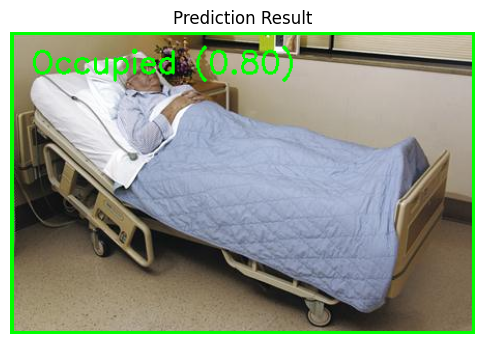

All probabilities: [    0.19912     0.80088]
Predicted class: occupied


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Get uploaded image name
img_path = list(uploaded.keys())[0]

# Read image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Predict
results = model(img_rgb)

probs = results[0].probs.data.cpu().numpy()
class_id = probs.argmax()
confidence = probs[class_id]

#  FIXED LABEL (AUTO FROM MODEL)
label = results[0].names[class_id]

# Convert label to readable format
if label.lower() in ["occupied", "occupied_bed"]:
    color = (0, 255, 0)   # GREEN
    display_label = f"Occupied ({confidence:.2f})"
else:
    color = (255, 0, 0)   # RED
    display_label = f"Empty ({confidence:.2f})"

# Draw rectangle
h, w, _ = img_rgb.shape
cv2.rectangle(img_rgb, (0,0), (w,h), color, 5)

# Put text
cv2.putText(img_rgb, display_label, (20,40),
            cv2.FONT_HERSHEY_SIMPLEX, 1,
            color, 2)

# Show image
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Prediction Result")
plt.show()

# DEBUG (IMPORTANT)
print("All probabilities:", probs)
print("Predicted class:", label)